<a href="https://colab.research.google.com/github/Ahmed-25800/Ai-Bootcamp/blob/main/Copy_of_1_Image_Classification_with_CNN_Pytorch_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 03
### 1.Convolution Neural Networks
### 2.Convolutions, Pooling, Activation functions, Dropout
### 3.Training, Predictions
### 4.VGG Architecture
### 4.Pretained CNN weights from Imagenet Data(VGG16)

In [3]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Data Cifar-10

In [5]:
import os
import tarfile
from torchvision.datasets.utils import download_url

In [6]:

# Dowload the dataset
dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(dataset_url, '.')

# Extract from archive
with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path='./data')

100%|██████████| 135M/135M [00:08<00:00, 15.9MB/s]
/tmp/ipykernel_755/576385917.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='./data')


In [8]:
data_dir = './data/cifar10'

print(os.listdir(data_dir))               # to check directories inside data_dir

classes = os.listdir(data_dir + "/test")   # to check directories inside train directory
print(classes)

airplane_files = os.listdir(data_dir + "/test/airplane")

print("No. of training examples for airplanes :", len(airplane_files))

['test', 'train']
['deer', 'frog', 'airplane', 'ship', 'dog', 'automobile', 'cat', 'horse', 'truck', 'bird']
No. of training examples for airplanes : 1000


In [9]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

In [10]:

# Training Transform
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# Validation/Test Transform
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

In [11]:
train_dataset_full = ImageFolder(
    data_dir + "/train",
    transform=train_transform
)

valid_dataset_full = ImageFolder(
    data_dir + "/train",
    transform=test_transform
)
train_dataset_full
valid_dataset_full

Dataset ImageFolder
    Number of datapoints: 50000
    Root location: ./data/cifar10/train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
           )

In [12]:
len(train_dataset_full)

image, label = train_dataset_full[40000]
print("image shape:",image.shape, "Label :", label)

image shape: torch.Size([3, 32, 32]) Label : 8


In [13]:

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [14]:
def show_image(img, label):
  Label = train_dataset_full.classes[label]
  print("Label :", Label, "[" + str(label) + "]")
  mean = torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)
  std = torch.tensor([0.2023,0.1994,0.2010]).view(3,1,1)

  img = img * std + mean
  image = img.permute(1,2,0)
  plt.imshow(image)

Label : automobile [1]
tensor(2.6952)
tensor(-2.4291)


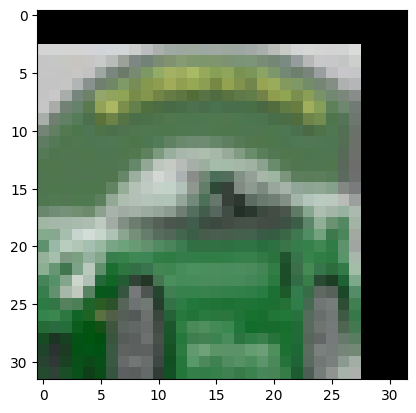

In [15]:
show_image(*train_dataset_full[9000])
print(image.max())
print(image.min())

In [16]:
from torch.utils.data import random_split,Subset

In [17]:
validation_size = 5000
training_size = len(train_dataset_full) - validation_size

generator = torch.Generator().manual_seed(42)

train_indices, valid_indices = random_split(
    range(len(train_dataset_full)),
    [training_size, validation_size],
    generator=generator
)

# Apply the same indices to both datasets
train_dataset = Subset(
    train_dataset_full,
    train_indices.indices
)

valid_dataset = Subset(
    valid_dataset_full,
    valid_indices.indices
)

In [18]:
from torch.utils.data.dataloader import DataLoader

batch_size=64

In [19]:
train_dl = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)

valid_dl= DataLoader(valid_dataset, batch_size, num_workers=2, pin_memory=True)

# Data Visualizing

In [20]:
from torchvision.utils import make_grid

In [21]:
def show_batch(data_loader):

  for images, labels in data_loader:

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xticks([]); ax.set_yticks([]);

    ax.imshow(make_grid(images, nrow=16).permute(1,2,0))     # as in tensor the order is C x W x H, so to show image we need order of W x H X C

    break


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


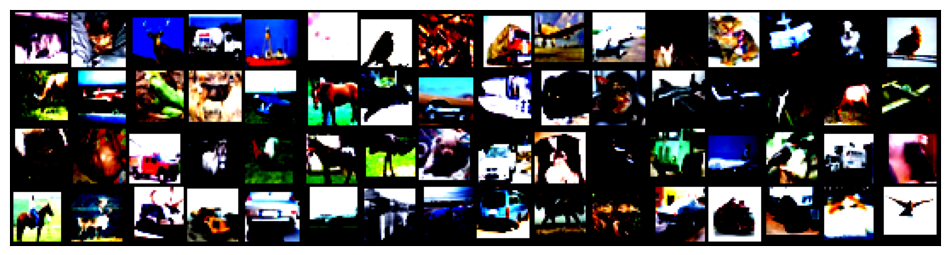

In [22]:
show_batch(train_dl)

# CNN Models

In [23]:

class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3,3), stride=1, padding=1)
        self.act1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3,3), stride=1, padding=1)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))

        self.flat = nn.Flatten()

        self.fc3 = nn.Linear(8192, 512)
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):
        # input 3x32x32, output 32x32x32
        x = self.act1(self.conv1(x))
        # input 32x32x32, output 32x32x32
        x = self.act2(self.conv2(x))
        # input 32x32x32, output 32x16x16
        x = self.pool2(x)
        # input 32x16x16, output 8192
        x = self.flat(x)
        # input 8192, output 512
        x = self.act3(self.fc3(x))
        x = self.drop3(x)
        # input 512, output 10
        x = self.fc4(x)
        return x

model = CIFAR10Model().to(device)

In [24]:
#VGG16

In [25]:
# import torch
# import torch.nn as nn
# class VGG16(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         # Block 1
#         self.block1 = nn.Sequential(
#             nn.Conv2d(3, 64, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(64, 64, 3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )
#         # Block 2
#         self.block2 = nn.Sequential(
#             nn.Conv2d(64, 128, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(128, 128, 3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )
#         # Block 3
#         self.block3 = nn.Sequential(
#             nn.Conv2d(128, 256, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(256, 256, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(256, 256, 3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )
#         # Block 4
#         self.block4 = nn.Sequential(
#             nn.Conv2d(256, 512, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(512, 512, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(512, 512, 3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )
#         # Block 5
#         self.block5 = nn.Sequential(
#             nn.Conv2d(512, 512, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(512, 512, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(512, 512, 3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )
#         self.flatten = nn.Flatten()
#         self.classifier = nn.Sequential(
#             nn.Linear(512 * 7 * 7, 4096),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(4096, 4096),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(4096, num_classes)
#         )
#     def forward(self, x):
#         x = self.block1(x)
#         x = self.block2(x)
#         x = self.block3(x)
#         x = self.block4(x)
#         x = self.block5(x)

#         x = self.flatten(x)
#         x = self.classifier(x)
#         return x
# vgg166=VGG16()
# print(vgg166)

# Training

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
epochs = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0
best_epoch = 0

patience = 3      # Number of epochs to wait
counter = 0       # Counts epochs without improvement

for epoch in range(epochs):

    # ==========================
    # TRAINING
    # ==========================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_dl:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dl)

    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in valid_dl:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss /= len(valid_dl)

    val_acc = 100 * correct / total

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    # ==========================
    # SAVE BEST MODEL
    # ==========================
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_epoch = epoch + 1

        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

        print(f"✅ Best model saved! Validation Accuracy = {best_val_acc:.2f}%")

    else:

        counter += 1

        print(f"No improvement ({counter}/{patience})")

    # ==========================
    # PRINT EPOCH RESULTS
    # ==========================
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.3f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.3f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    # ==========================
    # EARLY STOPPING
    # ==========================
    if counter >= patience:

        print("=" * 50)
        print("Early Stopping Triggered!")
        print("=" * 50)

        break

print("=" * 50)
print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Best Model Saved at Epoch : {best_epoch}")
print("=" * 50)






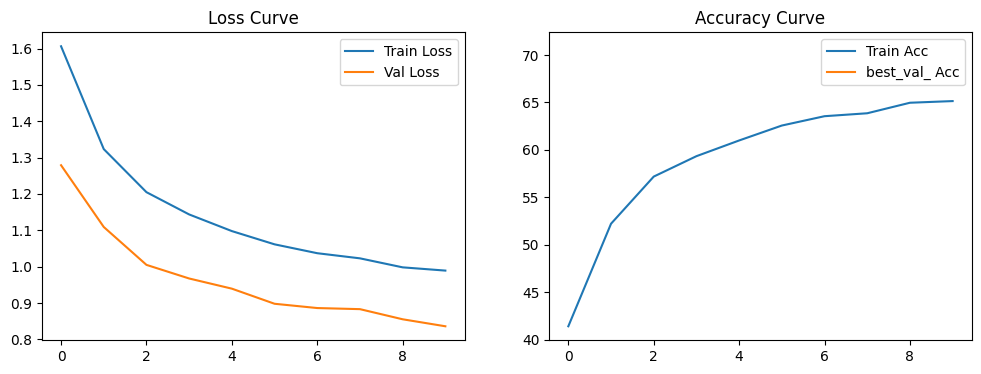

In [39]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(best_val_acc, label="best_val_ Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [1]:
# torch.save(model.state_dict(), "cifar10model.pth")
print("Model saved!")

Model saved!


In [2]:
model.state_dict()

NameError: name 'model' is not defined

In [28]:
test_dataset = ImageFolder(data_dir+'/test', transform=ToTensor())
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

<Figure size 800x800 with 0 Axes>

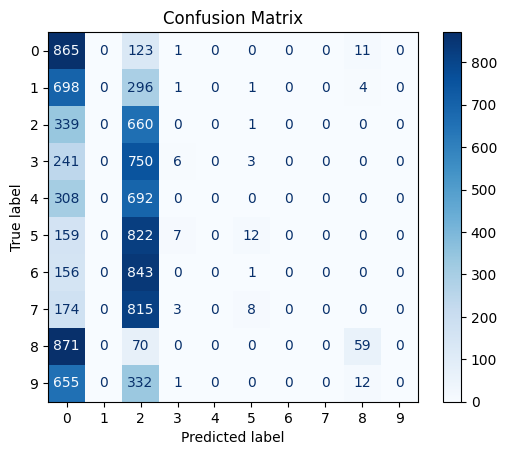

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import classification_report

# CIFAR-10 class names
class_names = classes

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print("📊 Classification Report:\n")
print(report)

📊 Classification Report:

              precision    recall  f1-score   support

       truck     0.1937    0.8650    0.3165      1000
         dog     0.0000    0.0000    0.0000      1000
       horse     0.1222    0.6600    0.2062      1000
    airplane     0.3158    0.0060    0.0118      1000
         cat     0.0000    0.0000    0.0000      1000
        ship     0.4615    0.0120    0.0234      1000
        bird     0.0000    0.0000    0.0000      1000
  automobile     0.0000    0.0000    0.0000      1000
        frog     0.6860    0.0590    0.1087      1000
        deer     0.0000    0.0000    0.0000      1000

    accuracy                         0.1602     10000
   macro avg     0.1779    0.1602    0.0666     10000
weighted avg     0.1779    0.1602    0.0666     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
# classes = trainset.classes

mis_images = []
mis_preds = []
mis_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                mis_images.append(images[i].cpu())
                mis_preds.append(preds[i].cpu())
                mis_labels.append(labels[i].cpu())

            if len(mis_images) >= 16:
                break
        if len(mis_images) >= 16:
            break

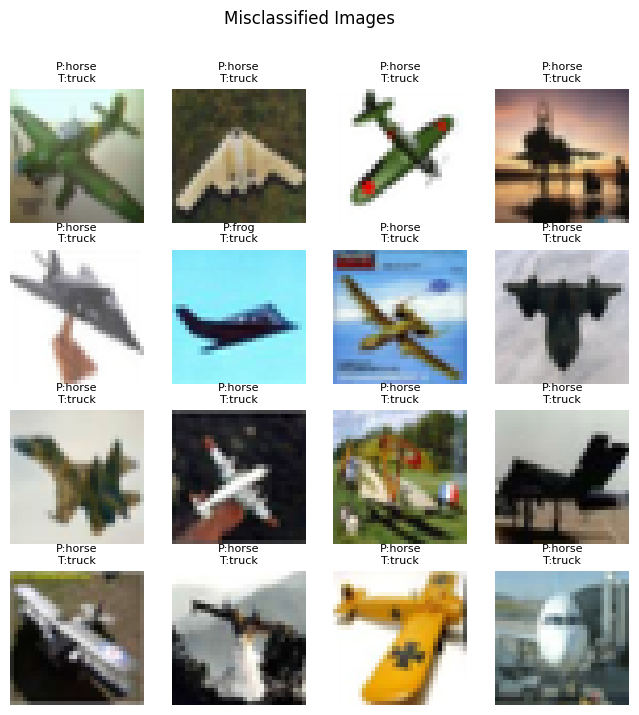

In [32]:
fig, ax = plt.subplots(4,4, figsize=(8,8))

for i in range(16):
    r, c = i//4, i%4
    img = mis_images[i].permute(1,2,0)

    ax[r][c].imshow(img)
    ax[r][c].set_title(
        f"P:{classes[mis_preds[i]]}\nT:{classes[mis_labels[i]]}",
        fontsize=8
    )
    ax[r][c].axis("off")

plt.suptitle("Misclassified Images")
plt.show()

In [33]:
model.load_state_dict(torch.load("cifar10model.pth"))

FileNotFoundError: [Errno 2] No such file or directory: 'cifar10model.pth'

In [ ]:
img, label = train_dataset[7]
#img = img * 0.5 + 0.5
plt.imshow(np.transpose(img.numpy(), (1,2,0)))
plt.title(f"Label: {classes[label]}")
plt.show()

# 1. Identify Problems In Model building and Training
# 2. Train the model with best approach you can understand


# Pre-trained CNN Models(ImageNet Data)
### VGG16

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import json
import urllib.request

# 1 Load pretrained VGG16
model = models.vgg16(pretrained=True)
model.eval()

# 2 Preprocessing (ImageNet standard)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3 Load image
img = Image.open("aero.jfif").convert("RGB")
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

# 4 Inference
with torch.no_grad():
    outputs = model(input_batch)
    probabilities = F.softmax(outputs, dim=1)


# 5 Load labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_idx = urllib.request.urlopen(url).read().decode("utf-8").splitlines()
print(class_idx)

In [ ]:

# 6 Top 3 Predictions
top3_prob, top3_catid = torch.topk(probabilities, 3)
print("Predictions:")

for i in range(top3_prob.size(1)):
    print(f"{class_idx[top3_catid[0][i]]} : {top3_prob[0][i].item():.4f}")

In [ ]:
class_idx[0]

In [ ]:
print(model)

In [ ]:
from torchinfo import summary
summary(model)